In [2]:
# ==================== IMPORTS ====================
%run CleanData.ipynb
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import LabelBinarizer
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# ==================== SARIMA RESIDUAL FUNCTION ====================
def fit_sarima_and_get_residual(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    try:
        model = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)
        return result.resid
    except:
        return np.zeros_like(series)


In [4]:
# ==================== FEATURE EXTRACTION ====================
# Apply SARIMA in parallel across rows (samples) — now using `.iloc`

X_residuals = Parallel(n_jobs=-1)(
    delayed(fit_sarima_and_get_residual)(X_train.iloc[i, :].values) for i in range(X_train.shape[0])
)
X_residuals = np.vstack(X_residuals)

X_test_residuals = Parallel(n_jobs=-1)(
    delayed(fit_sarima_and_get_residual)(X_test.iloc[i, :].values) for i in range(X_test.shape[0])
)
X_test_residuals = np.vstack(X_test_residuals)


In [8]:
# ==================== SANITIZE RESIDUALS ====================
def sanitize(X):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)  # replace invalid values
    return X.astype(np.float32)

X_residuals = sanitize(X_residuals)
X_test_residuals = sanitize(X_test_residuals)

In [9]:
# ==================== RANDOM FOREST ====================
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_residuals, y_train)
y_pred = rf.predict(X_test_residuals)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18952
           1       0.96      0.46      0.62       556
           2       0.98      0.72      0.83      1448
           3       0.80      0.30      0.43       162
           4       1.00      0.89      0.94      1608
           5       0.99      0.30      0.46      2077

    accuracy                           0.90     24803
   macro avg       0.93      0.61      0.70     24803
weighted avg       0.91      0.90      0.88     24803



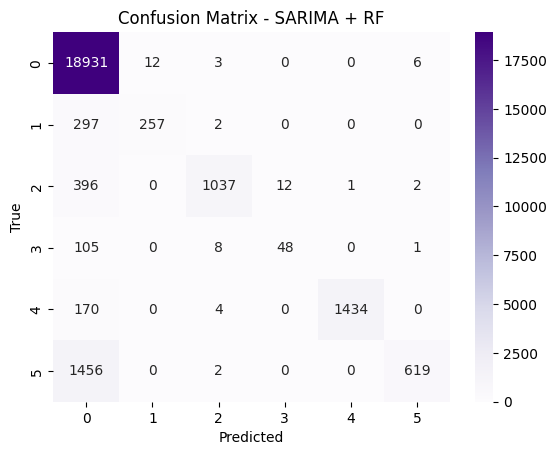

In [10]:
# ==================== EVALUATION ====================
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SARIMA + RF")
plt.show()


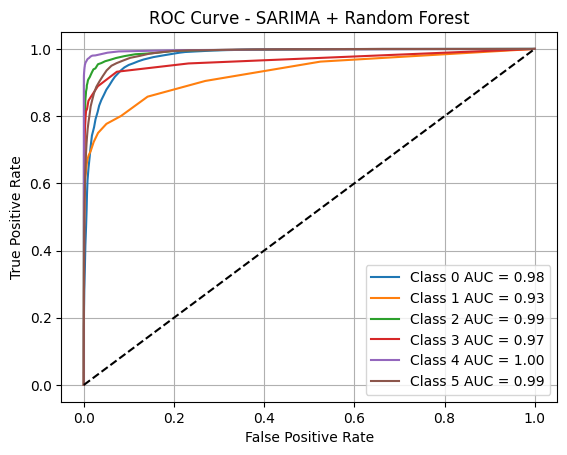

In [11]:
# ==================== ROC & AUC ====================
y_test_bin = LabelBinarizer().fit_transform(y_test)
y_prob = rf.predict_proba(X_test_residuals)

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} AUC = {auc_score:.2f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - SARIMA + Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
